<a href="https://colab.research.google.com/github/fabrito2006/Laboratorio-6-MID/blob/develop/Laboratorio_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 06 - Mineria de Datos
## Alumno: Torres Alvaradao Fabricio Ismael
## Ciclo y carrera: 5C28A

## 1. Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando las librerías de Python que se indican, haga lo siguiente:

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# Concat data
data = pd.concat([X, y], axis=1)

### a. Lea la base de datos, realice imputaciones, tratamiento de outliers y transformaciones de datos en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.

In [3]:
# Leemos la base de datos
data.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [4]:
# Funcion de etección de datos nulos
def columnas_con_nulos(data):
    columnas_nulas = data.columns[data.isnull().any()].tolist()
    return columnas_nulas

In [5]:
# Funcion para imputar valores nulos con la mediana
def rellenar_nulos_con_mediana(data, columnas):
    for columna in columnas:
        mediana = data[columna].median()
        data[columna] = data[columna].apply(lambda x: mediana if pd.isnull(x) else x)
        print(f"Se ha rellenado la columna '{columna}' con la mediana: {mediana}")
    return data

In [6]:
# Rellenar columnas
columnas_nulas = columnas_con_nulos(data)

data = rellenar_nulos_con_mediana(data, columnas_nulas)

Se ha rellenado la columna 'Bare_nuclei' con la mediana: 1.0


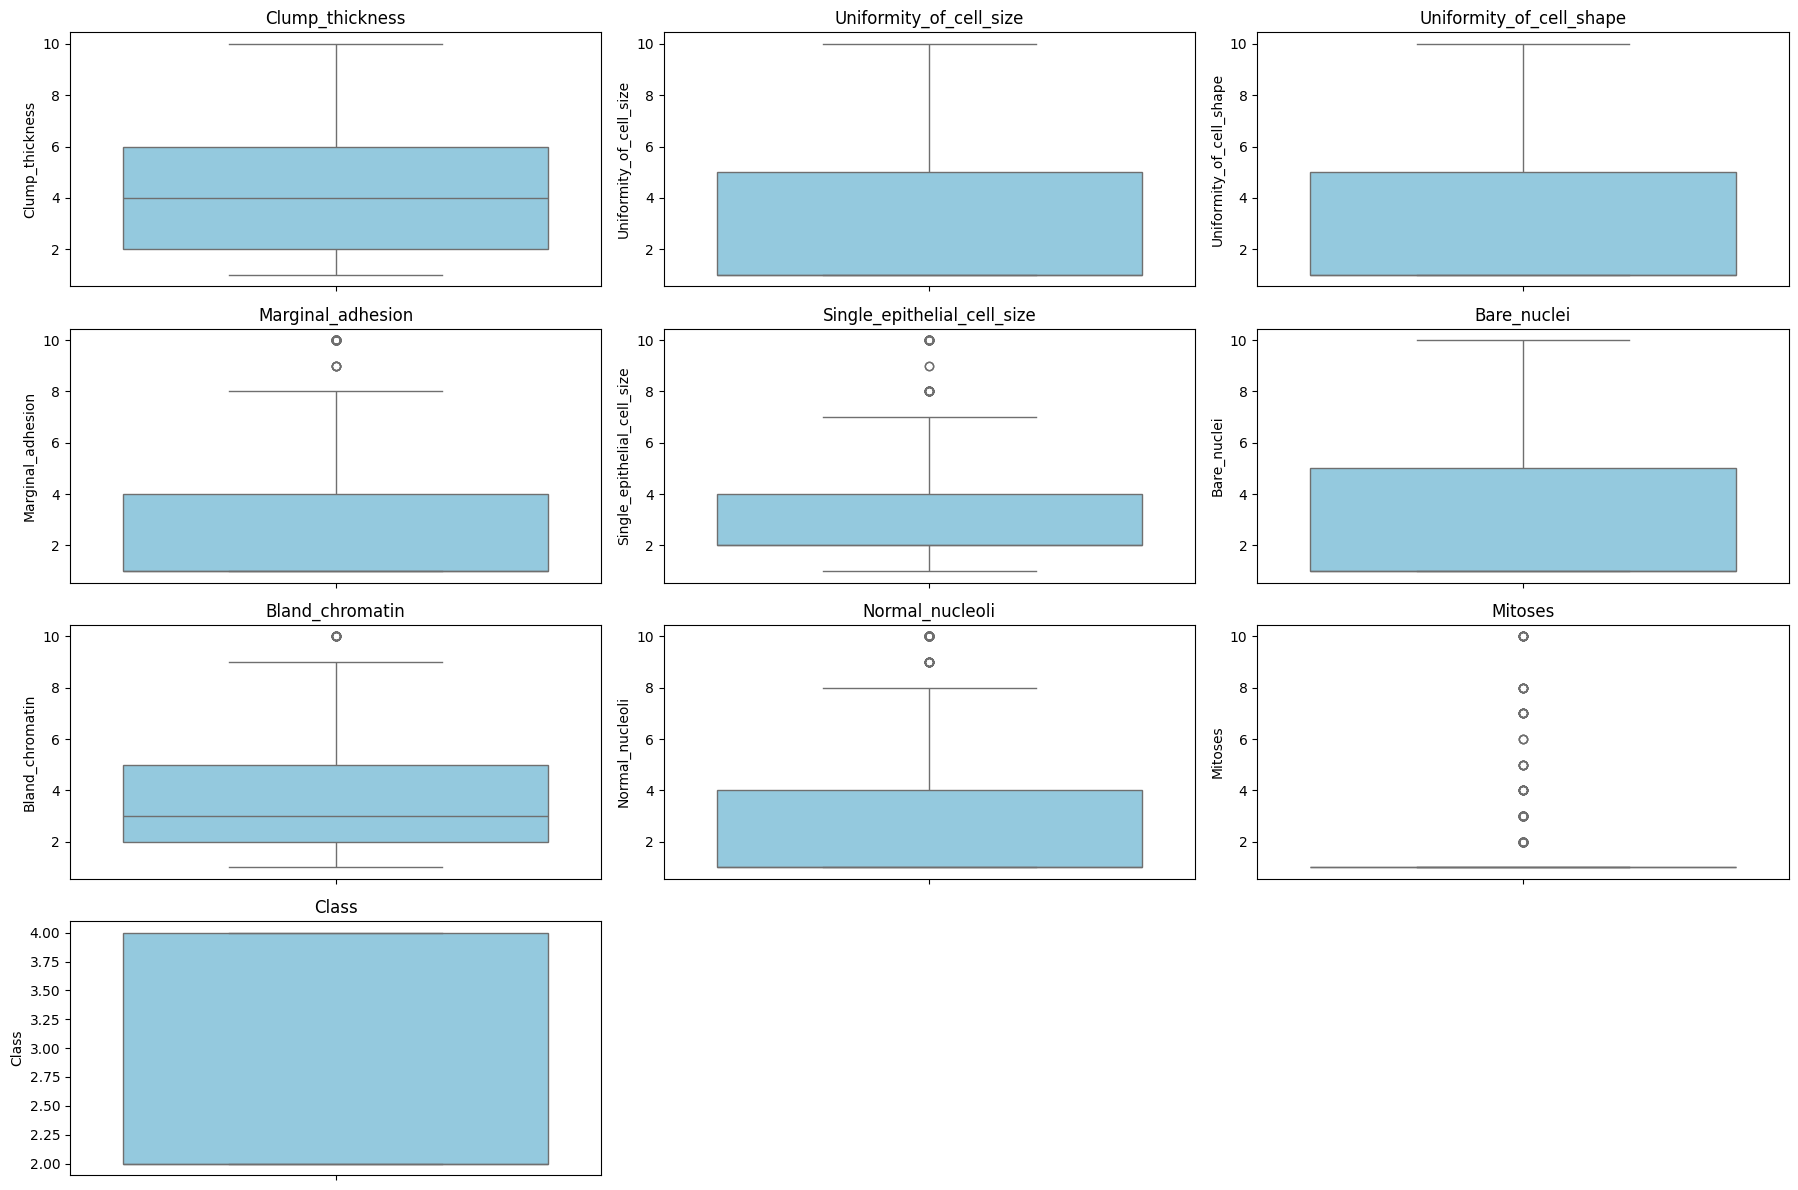

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
for i, col in enumerate(data.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=data[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [8]:
# Seleccionamos mitoses y eliminamos atipicos
Q1 = data['Bland_chromatin'].quantile(0.25)
Q3 = data['Bland_chromatin'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


data_filtrado = data[(data['Bland_chromatin'] >= lower_bound) & (data['Bland_chromatin'] <= upper_bound)]

# Verificamos que se hayan eliminado
print(len(data_filtrado))
print(len(data))

679
699


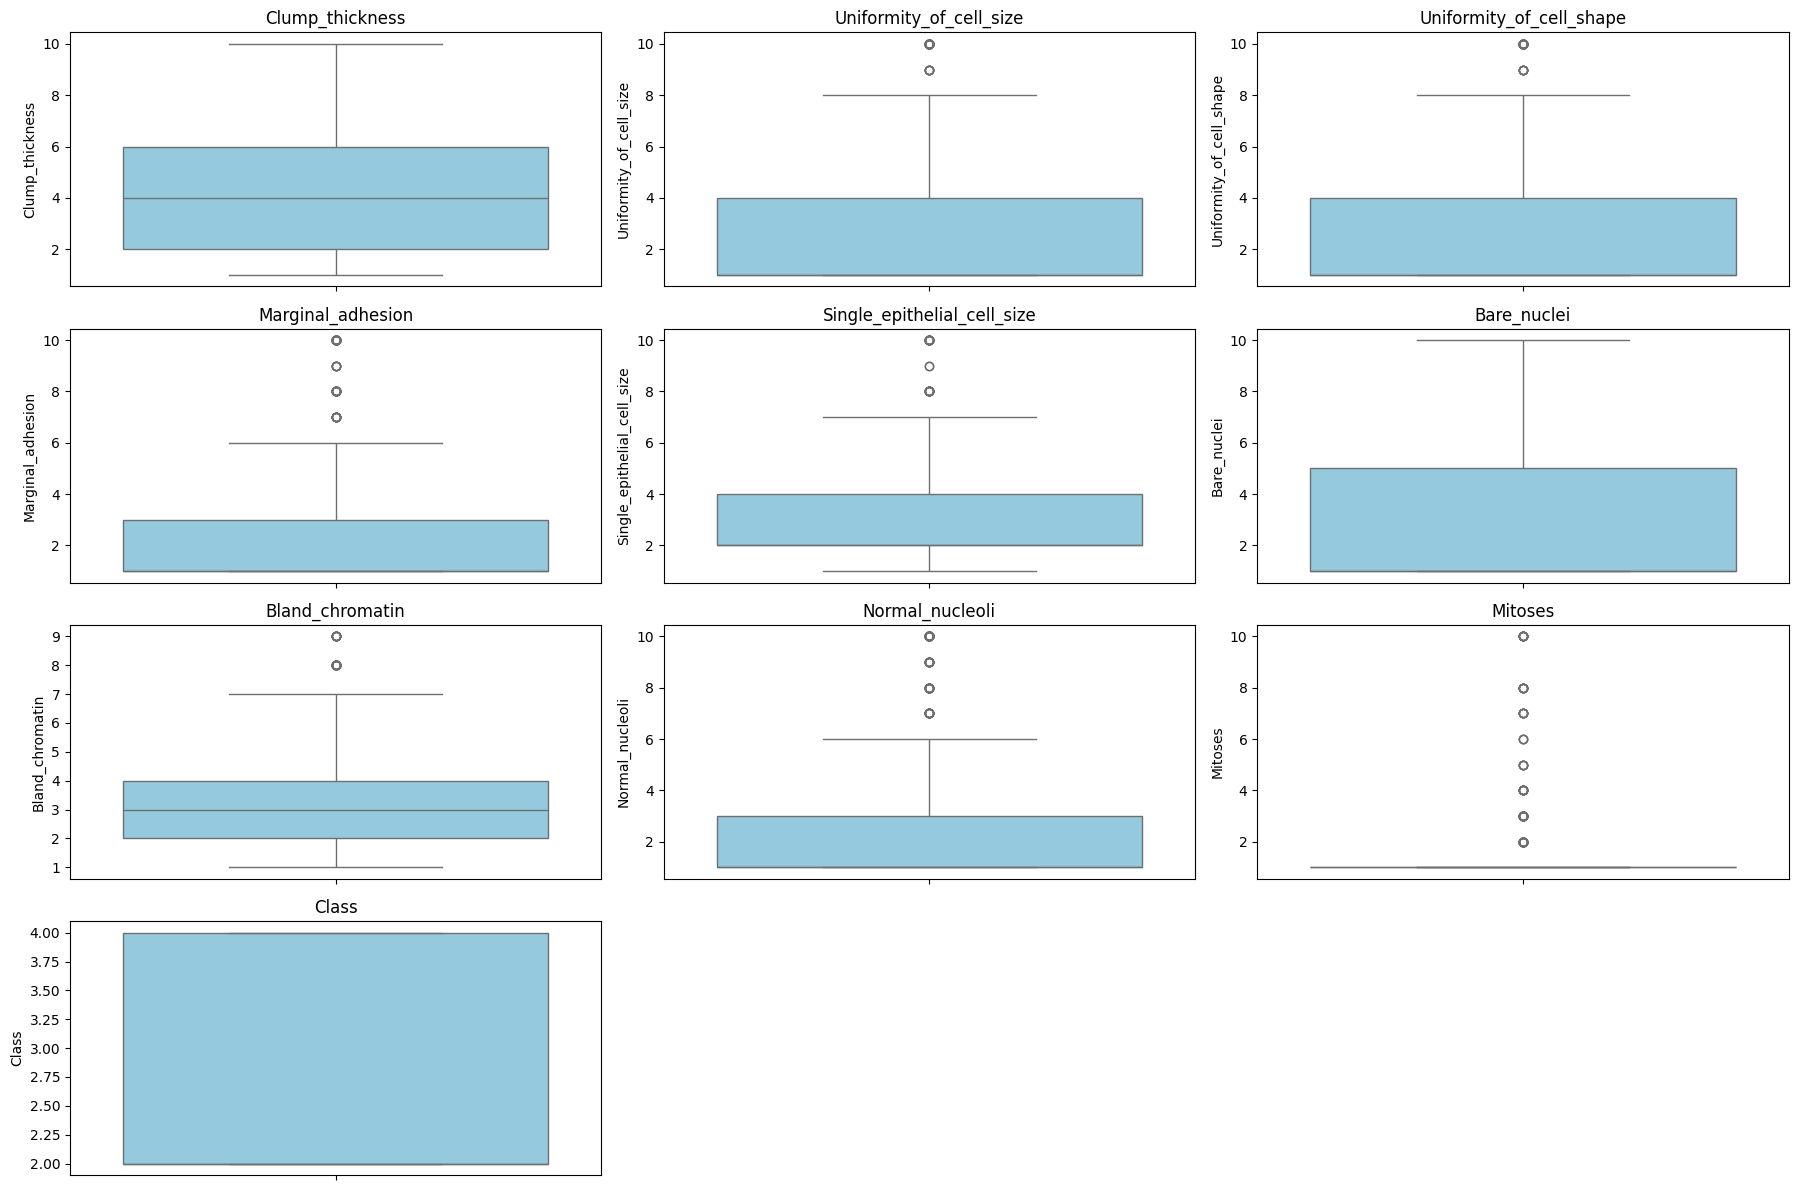

In [9]:
# Visualizamos de vuelta
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
for i, col in enumerate(data.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=data_filtrado[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

Observamos que, al eliminar los outliers (proceso probado con todas las variables), la cantidad de estos aumenta, lo que puede afectar negativamente el rendimiento del modelo. Por esta razón, hemos decidido no eliminar ningún outlier en este caso.

In [27]:
# Aseguramos que la variable Class este como numerica
data['Class'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 699 entries, 0 to 698
Series name: Class
Non-Null Count  Dtype
--------------  -----
699 non-null    int64
dtypes: int64(1)
memory usage: 5.6 KB


In [38]:
# Separamos la variable "Class"
X = data.drop('Class', axis=1)
y = data['Class']

In [39]:
# Reemplazamos los valores de la variable "Class"
y = y.replace({2: 0, 4: 1})

In [40]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento y prueba, con un 25% de los datos para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train, y_train

(     Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
 570                8                       10                         4   
 34                 3                        1                         2   
 506                8                       10                        10   
 514                6                        6                         7   
 567                4                        1                         1   
 ..               ...                      ...                       ...   
 359               10                        3                         5   
 192                5                        1                         1   
 629                4                        1                         1   
 559                5                        1                         1   
 684                1                        1                         1   
 
      Marginal_adhesion  Single_epithelial_cell_size  Bare_nuclei  \
 570             

## b. Genere el modelo k-NN y determine la cantidad de vecinos más adecuada con el método gráfico visto en clase. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.

In [41]:
# Aseguramos que la variable Class este como numerica
data['Class'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 699 entries, 0 to 698
Series name: Class
Non-Null Count  Dtype
--------------  -----
699 non-null    int64
dtypes: int64(1)
memory usage: 5.6 KB


In [42]:
# Generamos el modfelo k-NN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [43]:
import numpy as np
neighbors = np.arange(1,12)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  train_accuracy[i] = knn.score(X_train,y_train)
  test_accuracy[i] = knn.score(X_test,y_test)


Text(0, 0.5, 'Accuracy')

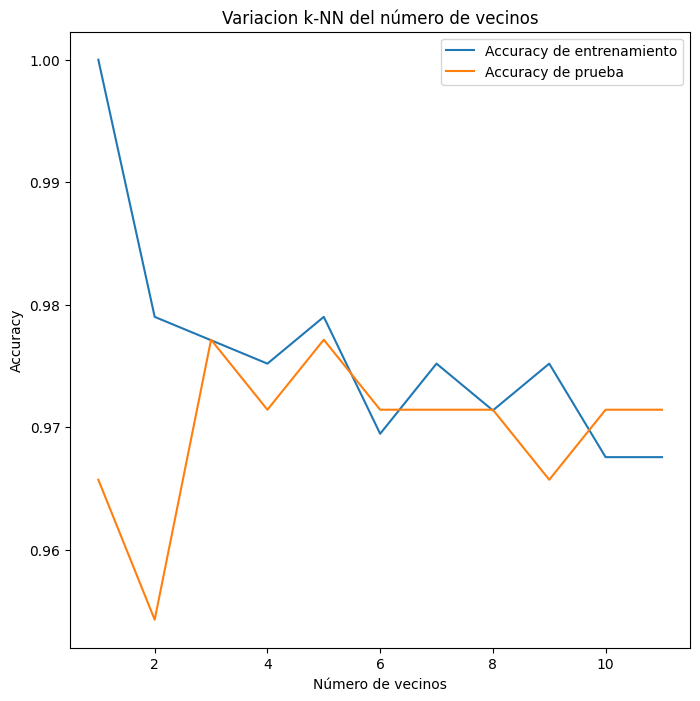

In [44]:
# Realizamos el gráfico
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.title('Variacion k-NN del número de vecinos')
plt.plot(neighbors,train_accuracy,label = 'Accuracy de entrenamiento')
plt.plot(neighbors,test_accuracy,label = 'Accuracy de prueba')
plt.legend()
plt.xlabel('Número de vecinos')
plt.ylabel('Accuracy')

In [45]:
# Generando el nuevo modelo k-NN
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [46]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
confusion_matrix(y_test,y_pred)

# Matriz de confusión como data frame
pd.crosstab(y_test,y_pred, rownames=['Verdaderos'], colnames=['Predichos'], margins=True)

Predichos,0,1,All
Verdaderos,,,
0,109,3,112
1,3,60,63
All,112,63,175


In [47]:
# Exactitud, precisión, sensibilidad y puntuación F1
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print('Exactitud = ', accuracy_score (y_test,y_pred))
print('Precisión = ',precision_score(y_test,y_pred))
print('Sensibilidad =',recall_score (y_test,y_pred))
print('Puntuación F1 =',f1_score (y_test,y_pred))

# Métricas de evaluación
from sklearn.metrics import classification_report
print(classification_report (y_test,y_pred))

Exactitud =  0.9657142857142857
Precisión =  0.9523809523809523
Sensibilidad = 0.9523809523809523
Puntuación F1 = 0.9523809523809523
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       112
           1       0.95      0.95      0.95        63

    accuracy                           0.97       175
   macro avg       0.96      0.96      0.96       175
weighted avg       0.97      0.97      0.97       175



<function matplotlib.pyplot.show(close=None, block=None)>

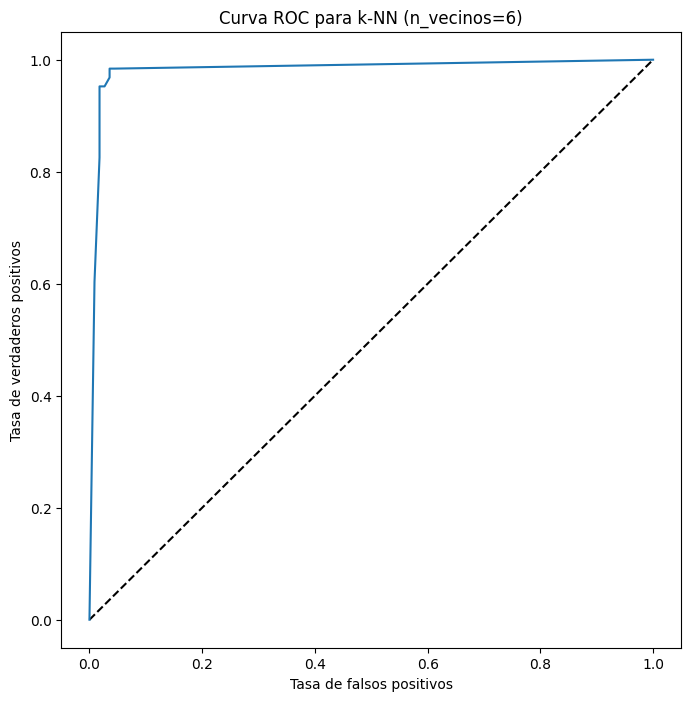

In [51]:
# Grafico de la curva roc
from sklearn.metrics import roc_curve

y_pred_proba = knn.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_pred_proba)

plt.figure(figsize=(8,8))
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr,tpr, label = 'k-NN')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC para k-NN (n_vecinos=6)')
plt.show

In [60]:
# Area bajo la curva ROC y coeficiente de Gini
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test,y_pred_proba)
roc_auc

np.float64(0.9827097505668936)

In [61]:
Gini = 2*roc_auc-1
Gini

np.float64(0.9654195011337872)

In [62]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=10)
score = knn.score(X_test,y_test)
print('Accuracy =', score)

Accuracy = 0.9657142857142857


In [65]:
# Accuracy para la validación cruzada k-fold
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn,X_train,y_train,cv=kf,scoring='accuracy')
print('Accuracy de la validacion cruzada',scores)
print('Media de la validacion cruzada',scores.mean())
score_pred = accuracy_score(y_test,y_pred)
print('Accuracy de los datos de prueba',score_pred)

Accuracy de la validacion cruzada [0.88679245 0.96226415 0.96226415 0.98113208 0.96153846 0.98076923
 0.98076923 0.96153846 0.98076923 0.98076923]
Media de la validacion cruzada 0.9638606676342525
Accuracy de los datos de prueba 0.9657142857142857


## c. Realice un balanceo de clases mediante la técnica SMOTE, vuelva a generar el modelo de clasificación, calcule sus métricas y compárelas con las del modelo sin balancear para ver si hubo o no mejoras.

<ipython-input-70-4bd00eb6ba9f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class',data=data,palette='hls')


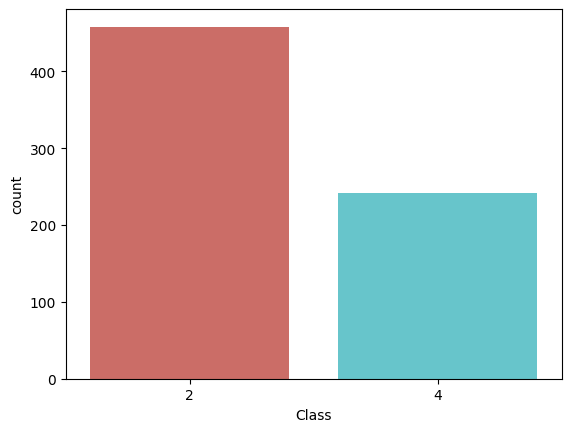

Class
2    458
4    241
Name: count, dtype: int64


In [70]:
# Visualizamos si hay un desbalance
import seaborn as sns
sns.countplot(x='Class',data=data,palette='hls')
plt.show()
print(data['Class'].value_counts())

In [71]:
!pip install imbalanced-Learn

In [74]:
# Aplicamos la tecnica de SMOTE y visualizamos la diferencia
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(sampling_strategy='minority')
X_train_bal, y_train_bal = smote.fit_resample(X_train,y_train)
print('Cantidad antes del SMOTE{}'.format(Counter(y_train)))
print('Cantidad despues del SMOTE{}'.format(Counter(y_train_bal)))

Cantidad antes del SMOTECounter({0: 346, 1: 178})
Cantidad despues del SMOTECounter({1: 346, 0: 346})


<ipython-input-75-2b2a4ac124cf>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_bal,data=data,palette='hls')


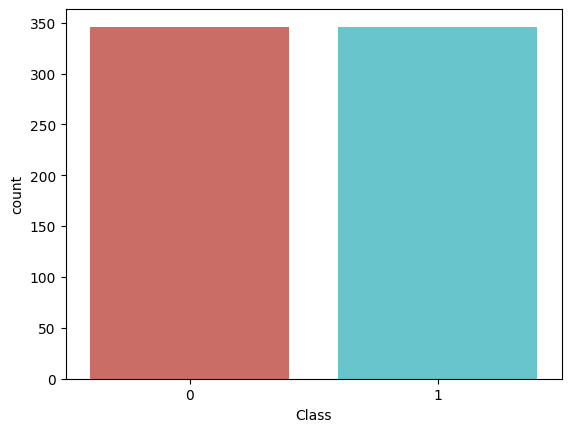

Class
1    346
0    346
Name: count, dtype: int64


In [75]:
# Visualizamos como se ve
sns.countplot(x=y_train_bal,data=data,palette='hls')
plt.show()
print(y_train_bal.value_counts())